In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from scipy.optimize import curve_fit

In [ ]:
dataset = pd.read_csv(r'C:\Users\Spandan Dutta\econometrics_project\data\processed\master_panel.csv',parse_dates=['date'], index_col='date')
tenors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 20, 30]
yield_cols = [f'yield_{t}y' for t in tenors]

In [ ]:
def nss(tenor, beta0, beta1, beta2, lambda1):
    factor1 = (1 - np.exp(-tenor/lambda1)) / (tenor/lambda1)
    factor2 = factor1 - np.exp(-tenor/lambda1)
    return beta0 + (beta1*factor1) + (beta2*factor2)

In [7]:
tenor = np.array(tenors, dtype = float)
nss_params = []
for date, row in dataset[yield_cols].iterrows():
    yields = row.values.astype(float)
    if np.sum(np.isnan(yields)) > 3:
        continue
    mask = ~np.isnan(yields) #removing nan values
    tenor_fit = tenor[mask]
    y_fit = yields[mask]
    popt,_= curve_fit(
        nss, tenor_fit, y_fit,
        p0     = [6.0, -1.0, 1.0, 1.5],
        bounds = ([0, -10, -10, 0.1], [15, 10, 10, 10]),
        maxfev = 5000)
    nss_params.append({"date":date, "beta0" : popt[0],"beta1" : popt[1], "beta2" : popt[2], "lambda1" : popt[3] })
nss_df = pd.DataFrame(nss_params).set_index('date')  
print(nss_params)

[{'date': Timestamp('2021-04-30 00:00:00'), 'beta0': np.float64(6.821385966028571), 'beta1': np.float64(-4.045139405345144), 'beta2': np.float64(3.579540125239076), 'lambda1': np.float64(3.5945078650929276)}, {'date': Timestamp('2021-05-31 00:00:00'), 'beta0': np.float64(7.188177454738008), 'beta1': np.float64(-4.2224334158189825), 'beta2': np.float64(2.48061582376851), 'lambda1': np.float64(3.50310103380619)}, {'date': Timestamp('2021-06-30 00:00:00'), 'beta0': np.float64(7.3234143092540025), 'beta1': np.float64(-4.279895934376149), 'beta2': np.float64(0.974670716850679), 'lambda1': np.float64(2.35824711527366)}, {'date': Timestamp('2021-07-31 00:00:00'), 'beta0': np.float64(7.514216298822011), 'beta1': np.float64(-4.8206257637196455), 'beta2': np.float64(0.9153032095734238), 'lambda1': np.float64(2.3748413008435088)}, {'date': Timestamp('2021-08-31 00:00:00'), 'beta0': np.float64(7.491444669724112), 'beta1': np.float64(-4.866842375534745), 'beta2': np.float64(1.1406387533524678), 'la

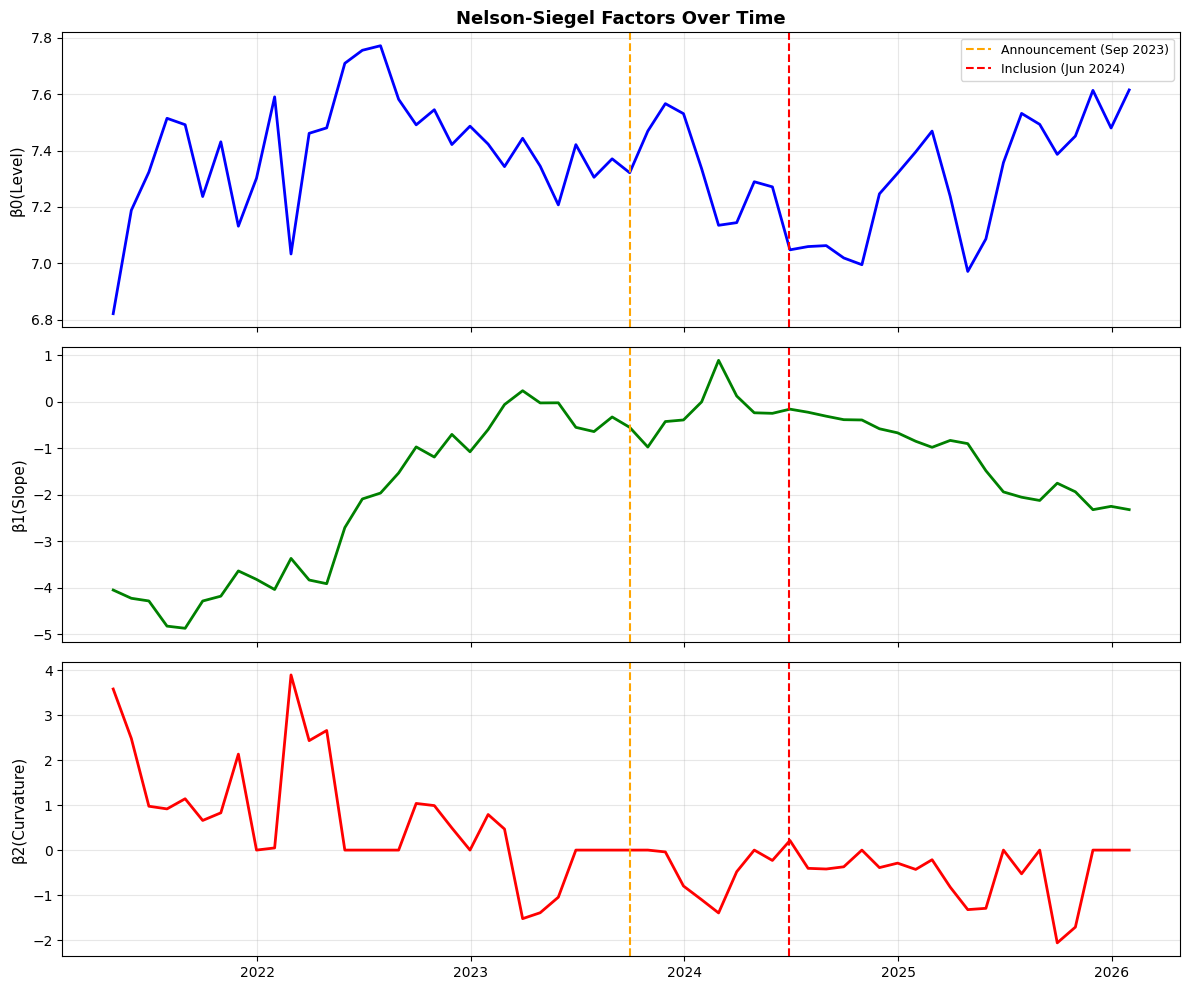

In [9]:
#visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(nss_df.index, nss_df['beta0'], color='blue', linewidth=2)
axes[0].set_ylabel('β0(Level)', fontsize=11)
axes[0].set_title('Nelson-Siegel Factors Over Time', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(nss_df.index, nss_df['beta1'], color='green', linewidth=2)
axes[1].set_ylabel('β1(Slope)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(nss_df.index, nss_df['beta2'], color='red', linewidth=2)
axes[2].set_ylabel('β2(Curvature)', fontsize=11)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.axvline(pd.Timestamp('2023-09-30'), color='orange', linestyle='--',linewidth=1.5, label='Announcement (Sep 2023)')
    ax.axvline(pd.Timestamp('2024-06-28'), color='red', linestyle='--',linewidth=1.5, label='Inclusion (Jun 2024)')

axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\nelson_siegel_factors.png',dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Merge NS factors with main dataset
nss_merged = dataset.join(nss_df, how='inner')
#first differences
nss_merged['d_beta0'] = nss_merged['beta0'].diff()
nss_merged['d_beta1'] = nss_merged['beta1'].diff()
nss_merged['d_beta2'] = nss_merged['beta2'].diff()
controls = ['d_us_10y', 'd_vix', 'd_dxy', 'd_brent', 'repo_rate', 'cpi', 'd_laf_net']
diff_cols = ['us_10y', 'vix', 'dxy', 'brent', 'laf_net']
for col in diff_cols:
    nss_merged[f'd_{col}'] = nss_merged[col].diff()

In [13]:
#beta0
reg_vars = ['d_beta0', 'fpi', 'jpmorgan_weight'] + controls
df_b0 = nss_merged[reg_vars].dropna()
X = sm.add_constant(df_b0[controls])
iv_b0 = IV2SLS(df_b0['d_beta0'],X,df_b0[['fpi']],instruments = df_b0[['jpmorgan_weight']]).fit(cov_type='robust')
print(iv_b0)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                d_beta0   R-squared:                      0.1656
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0101
No. Observations:                  47   F-statistic:                    15.212
Date:                Fri, Apr 10 2026   P-value (F-stat)                0.0552
Time:                        06:16:18   Distribution:                  chi2(8)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.3973     1.5952     0.2490     0.8033     -2.7293      3.5238
d_us_10y       0.1254     0.1122     1.1177     0.26

In [15]:
#Beta1
reg_vars = ['d_beta1', 'fpi', 'jpmorgan_weight'] + controls
df_b1 = nss_merged[reg_vars].dropna()
X1 = sm.add_constant(df_b1[controls])
iv_b1 = IV2SLS(df_b1['d_beta1'],X1,df_b1[['fpi']],instruments = df_b1[['jpmorgan_weight']]).fit(cov_type='robust')
print(iv_b1)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                d_beta1   R-squared:                      0.1574
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0200
No. Observations:                  47   F-statistic:                    8.8090
Date:                Fri, Apr 10 2026   P-value (F-stat)                0.3587
Time:                        06:18:01   Distribution:                  chi2(8)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -0.7499     4.4256    -0.1695     0.8654     -9.4240      7.9242
d_us_10y      -0.4813     0.2291    -2.1005     0.03

In [20]:
#beta2
reg_vars = ['d_beta2', 'fpi', 'jpmorgan_weight'] + controls
df_b2 = nss_merged[reg_vars].dropna()
X2 = sm.add_constant(df_b2[controls])
iv_b2 = IV2SLS(df_b2['d_beta2'],X2,df_b2[['fpi']],instruments = df_b2[['jpmorgan_weight']]).fit(cov_type='robust')
print(iv_b2)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                d_beta2   R-squared:                      0.0705
Estimator:                    IV-2SLS   Adj. R-squared:                -0.1252
No. Observations:                  47   F-statistic:                    8.4375
Date:                Fri, Apr 10 2026   P-value (F-stat)                0.3919
Time:                        06:23:46   Distribution:                  chi2(8)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -3.7147     9.1537    -0.4058     0.6849     -21.656      14.226
d_us_10y       0.1032     0.5701     0.1811     0.85